In [1]:
import numpy as np
import corner
import matplotlib.pyplot as plt
import scipy
import pandas as pd

plt.rcParams['figure.figsize']=(10.4,5.4)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

### Data set 1 - 97 Zr gsf high energy

In [6]:
# reading the half data set of 97 Zr

df_97=pd.read_csv("input_data/gsf_97Zr.csv")

# convert to python arrays
energy_97=df_97["energy"].values # as numpy array
gsf_97=df_97["gsf"].values 
error_97=df_97["errors"].values

### Data set 2 - 100 Zr gsf full

In [7]:
# reading the full data set of 100Zr

df_100=pd.read_csv("input_data/gsf_100Zr_baseline_full.csv")

# convert to python arrays
energy_100=df_100["energy"].values # as numpy array
gsf_100=df_100["gsf"].values 
error_100=df_100["errors"].values


### plot of both data sets

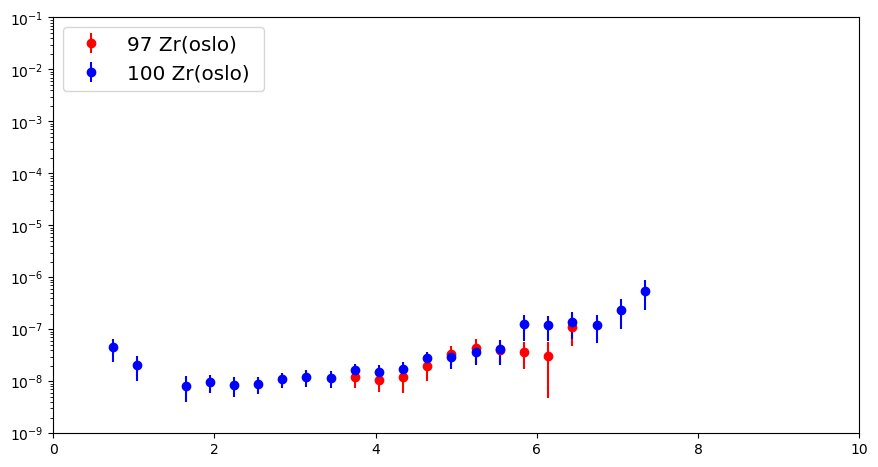

In [8]:

fig = plt.figure()


plt.errorbar(energy_97, gsf_97,yerr=error_97,fmt="o", color="r",ecolor='r',label='97 Zr(oslo) ')
plt.errorbar(energy_100, gsf_100,yerr=error_100,fmt="o", color="b",ecolor='b',label='100 Zr(oslo) ')


plt.yscale("log")

plt.xlim(0, 10)
plt.ylim(10**(-9),10**(-1))

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

## Pulling the base data of gsf and interpolation to the experimental energy

In [10]:
df_construct = pd.read_pickle("interp_data/master_base_gsf.pkl")

# for 97 Zr
intp_gsf_97 = np.interp(energy_97, df_construct['energy'].values, df_construct['gsf'].values)
intp_e1_97 = np.interp(energy_97,  df_construct['energy'].values, df_construct['f(E1)'].values)
intp_m1_97 = np.interp(energy_97, df_construct['energy'].values, df_construct['f(M1)'].values)

print("shape of small set ", intp_m1_97.shape)

# for 100 Zr
intp_gsf_100 = np.interp(energy_100, df_construct['energy'].values, df_construct['gsf'].values)
intp_e1_100 = np.interp(energy_100,  df_construct['energy'].values, df_construct['f(E1)'].values)
intp_m1_100 = np.interp(energy_100, df_construct['energy'].values, df_construct['f(M1)'].values)

print("shape of large set ", intp_m1_100.shape)



shape of small set  (10,)
shape of large set  (22,)


## Input functions for likelihood

### 1. 97 Zr GSf

In [11]:
# this goes into metropolis algorithm
def model_97(j,params):

    # f(e1)  --- constants
    ftable=1
    C= 0
    U =  6.827386
    eta =3
    
    #f(M1)-- constants
    upbende =0
    upbendc = 10**(-6)

    final_upbend = upbende+params[2]
    
    # f(e1) construction in accordance with TALYS 2.0
    e1= params[0]*ftable * intp_e1_97[j] +  (C* (U-energy_97[j]))/(1+np.exp(energy_97[j]-eta))
    
    #f(m1) construction in accordance with TALYS 2.0
    m1 = intp_m1_97[j] +  params[1]*upbendc * np.exp(-1*(final_upbend)*energy_97[j])
    

    gsf_97 = m1+e1
    
    return gsf_97

### 1. 100 Zr GSf

In [12]:
# this goes into metropolis algorithm
def model_100(j,params):

    # f(e1)  --- constants
    ftable=1
    C= 0
    U =  6.827386
    eta =3
    
    #f(M1)-- constants
    upbende =0
    upbendc = 10**(-6)

    final_upbend = upbende+params[2]
    
    # f(e1) construction
    e1= params[0]*ftable * intp_e1_100[j] +  (C* (U-energy_100[j]))/(1+np.exp(energy_100[j]-eta))
    
    #f(m1) construction
    m1 = intp_m1_100[j] +  params[1]*upbendc * np.exp(-1*(final_upbend)*energy_100[j])
    
    gsf = m1+e1

   
    # transformed gsf that must match the 100Zr data

    gsf_100 = params[3]* np.exp(params[4]*energy_100[j])*gsf
    
 

    return gsf_100

## Likelihood and prior definition starts here

In [18]:
# Define the likelihood function for given errors sigma
def likelihood(params,arguments):
#Assumed format for data=[xvals,yvals]
    data_97,data_100,model_97_Zr,model_100_Zr,sigmas_97,sigmas_100 = arguments
    likelihood_log_val_97=0
    likelihood_log_val_100 =0
    

    for i in range(len(data_97[0])):
        # likelihood that compares the model with 97Zr at high energy
        likelihood_log_val_97=likelihood_log_val_97-1/2*((data_97[1][i] - model_97_Zr(i,params)) / sigmas_97[i])**2\
        -np.log(2*np.pi*sigmas_97[i]**2)/2

    for j in range(len(data_100[0])):
        # likelihood that compares the transformed model with 100Zr for full range
        likelihood_log_val_100=likelihood_log_val_100-1/2*((data_100[1][j] - model_100_Zr(j,params)) / sigmas_100[j])**2\
        -np.log(2*np.pi*sigmas_100[j]**2)/2          

       
      
    likelihood_log_val = likelihood_log_val_97+likelihood_log_val_100

    return np.exp(likelihood_log_val)

# Define the prior function
def prior_model(params_vals,arguments):
    params0,params0_Cov_Inv_matrix=arguments

    # hard bounds on upbende and upbendc as required by TALYS2.0

    if (params_vals[1]<0 or params_vals[1]>10 or params_vals[2]<0 or params_vals[2]>10):
        return 0
    
    else: 
  
        mu=np.array(params_vals)-np.array(params0)
        params_size=len(params_vals)
        return (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)



## Markov Chain Monte Carlo (MCMC) 

In [19]:


def metropolis(data_97,sigma_97,data_100,sigma_100, prior,prior_arguments, likelihood,model_1,model_2,\
               num_iterations, step_size,initial):
#    step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data_97,data_100,model_1,model_2, sigma_97,sigma_100]
    #initial_parameters=prior_arguments[0]
    #thermalizing
    burn_samples=100000
    # Set the initial state of the chain
    params_current=initial
    params_list=[]
    posterior_list=[]
    
    acceptance_times=0
    
    cov_step_size=np.diag(step_size)**2
    
    posterior_current=(likelihood(params_current,likelihood_arguments))*(prior(params_current,\
                                                                               prior_arguments))
    
    # Run the Metropolis-Hastings algorithm for burning
    for i in range(burn_samples):
        # Propose a new state for the chain
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*(prior(params_proposed,\
                                                                               prior_arguments))
      
        
        
        
        acceptance_prob = min(1, posterior_proposed / posterior_current)


        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*\
        (prior(params_proposed,prior_arguments))
        

    



        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1

        # Store the current state
        params_list.append(params_current)
        posterior_list.append(posterior_current)
        
    
    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see. 
    print(acceptance_times/num_iterations*100,"%")
    
    return(np.array(params_list),np.array(posterior_list),\
           acceptance_times/num_iterations*100)



### Running the Full MCMC Setup

In [20]:

np.random.seed(142857)

diff_walkers =[]
diff_walkers_posterior =[]



# different initial conditions that you could choose for the MCMC walker 
initial = [
    [0, 0, 0, 0, 0],
    [3, 0.1,1, 1, 0.1 ],
    [2, 0.4,2, 3, -0.15],
    [1, 0.25, 1.5, 1.5, 0.07],
    [1.5, 0.3, 1.8, 2, -0.07],
    [ 0.45793316 ,-4.09264098, 10.62857632 , 4.02021795 ,-0.17415865],
    [2, 0,2, 2, 0.00],
    [2, 0,6, 2, 0.00],
    [1,1,3,1,0],
    [3,1,3,1,0],
    [1,0.5,4,2,-0.1],
    [1,1,1,1,1]
]



#Setting up the prior with a mean and standard for each parameter ftable , upbende, upbendc,B, alpha 
prior_arguments=[[0.0,0,0,0,0.00],np.linalg.inv(np.diag([7**2,15**2,15**2,15**2,0.038025]))]

#Doing the Metropolis sampling for 100000 values


# running for diiferent walkers with different initial conditions over 300000 steps and steps as given in [...] for each parameter
for p in range(0,1):
    print(initial[p])
    results_A=metropolis([energy_97,gsf_97],error_97,[energy_100,gsf_100],error_100,prior_model,\
                         prior_arguments, likelihood,model_97,model_100,300000,   [0.04,0.4,0.2000400,0.2045,0.050],initial[p])
    

    all_chains =results_A[0]
    all_chains_posterior = results_A[1]
    
    diff_walkers.append(all_chains)
    diff_walkers_posterior.append(all_chains_posterior)




diff_walkers = np.array(diff_walkers)
diff_walkers_posterior= np.array(diff_walkers_posterior)






[0, 0, 0, 0, 0]
34.715 %


### Drawing different chains in MCMC

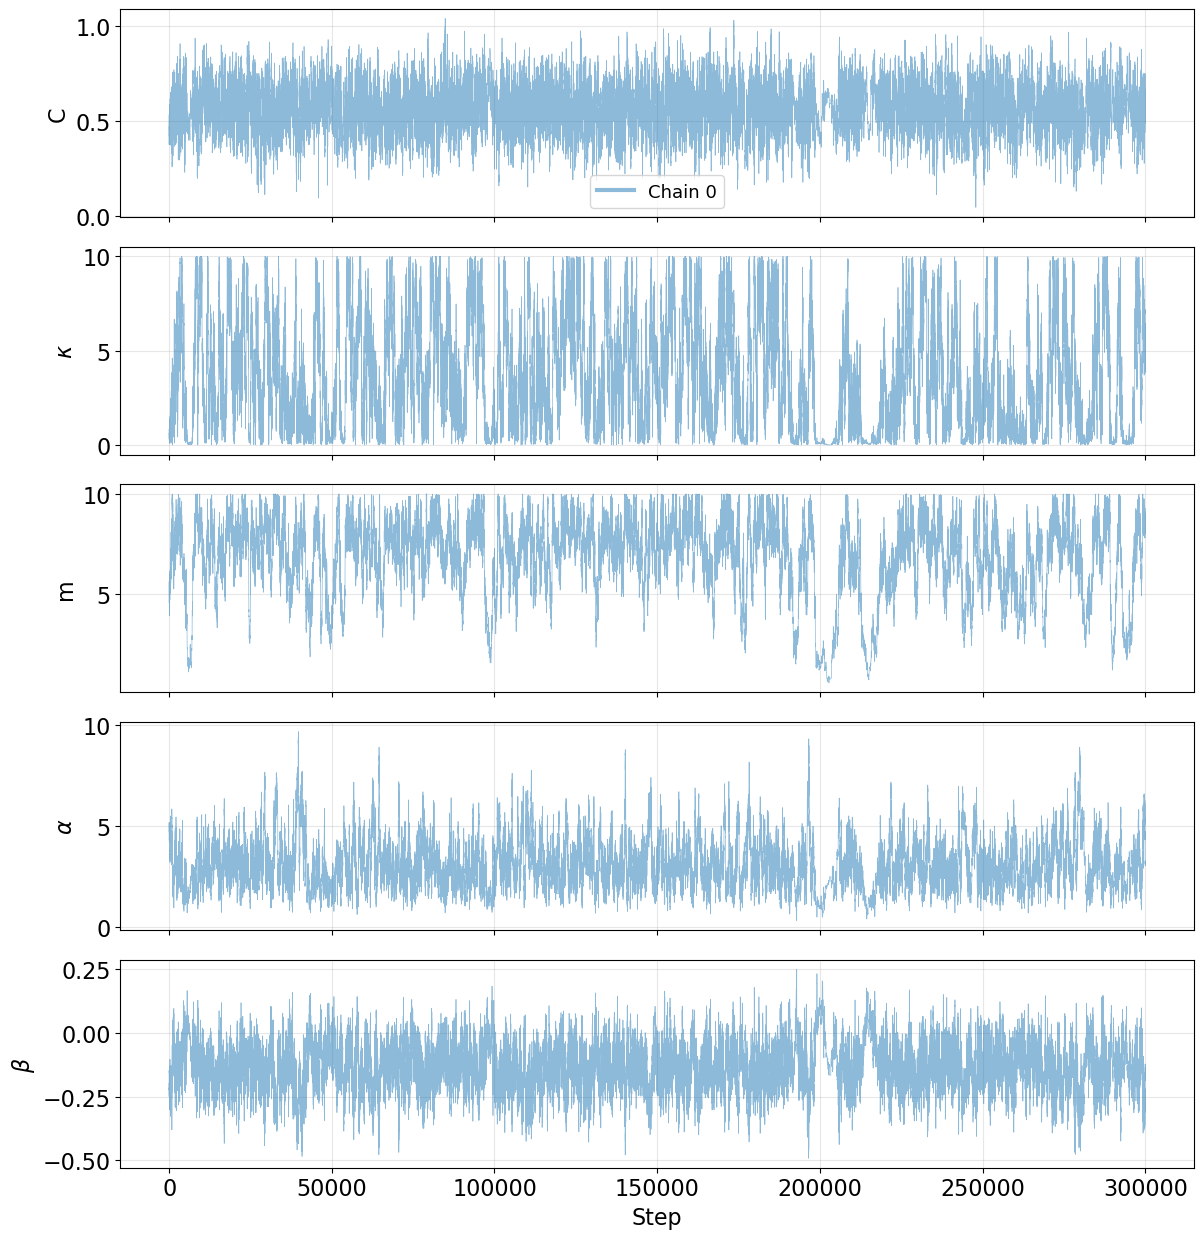

In [21]:



# samples.shape = (6, 80000, 5)

nchains, nsamples, nparams = diff_walkers.shape

fig, axes = plt.subplots(nparams, 1,
                         figsize=(12, 2.5*nparams),
                         sharex=True)

param_labels = ['C', r'$\kappa$', 'm', r'$\alpha$', r'$\beta$']



for p in range(nparams):
    for chain in range(nchains):
        axes[p].plot(diff_walkers[chain, :, p],
                     alpha=0.5,
                     lw=0.5,
                     label=f'Chain {chain}')

    axes[p].set_ylabel(param_labels[p], fontsize=16)
    axes[p].tick_params(axis='both', labelsize=16)
    axes[p].grid(alpha=0.3)

axes[-1].set_xlabel('Step', fontsize=16)

# Only show legend once
legend=axes[0].legend(ncol=3,fontsize=13)

for line in legend.get_lines():
    line.set_linewidth(3)

plt.tight_layout()
plt.show()

In [25]:
# selecting a chain for corner plot

all_chains_sel = diff_walkers[0]
all_chains_post_sel =diff_walkers_posterior[0]


### Corner plot for a given chain

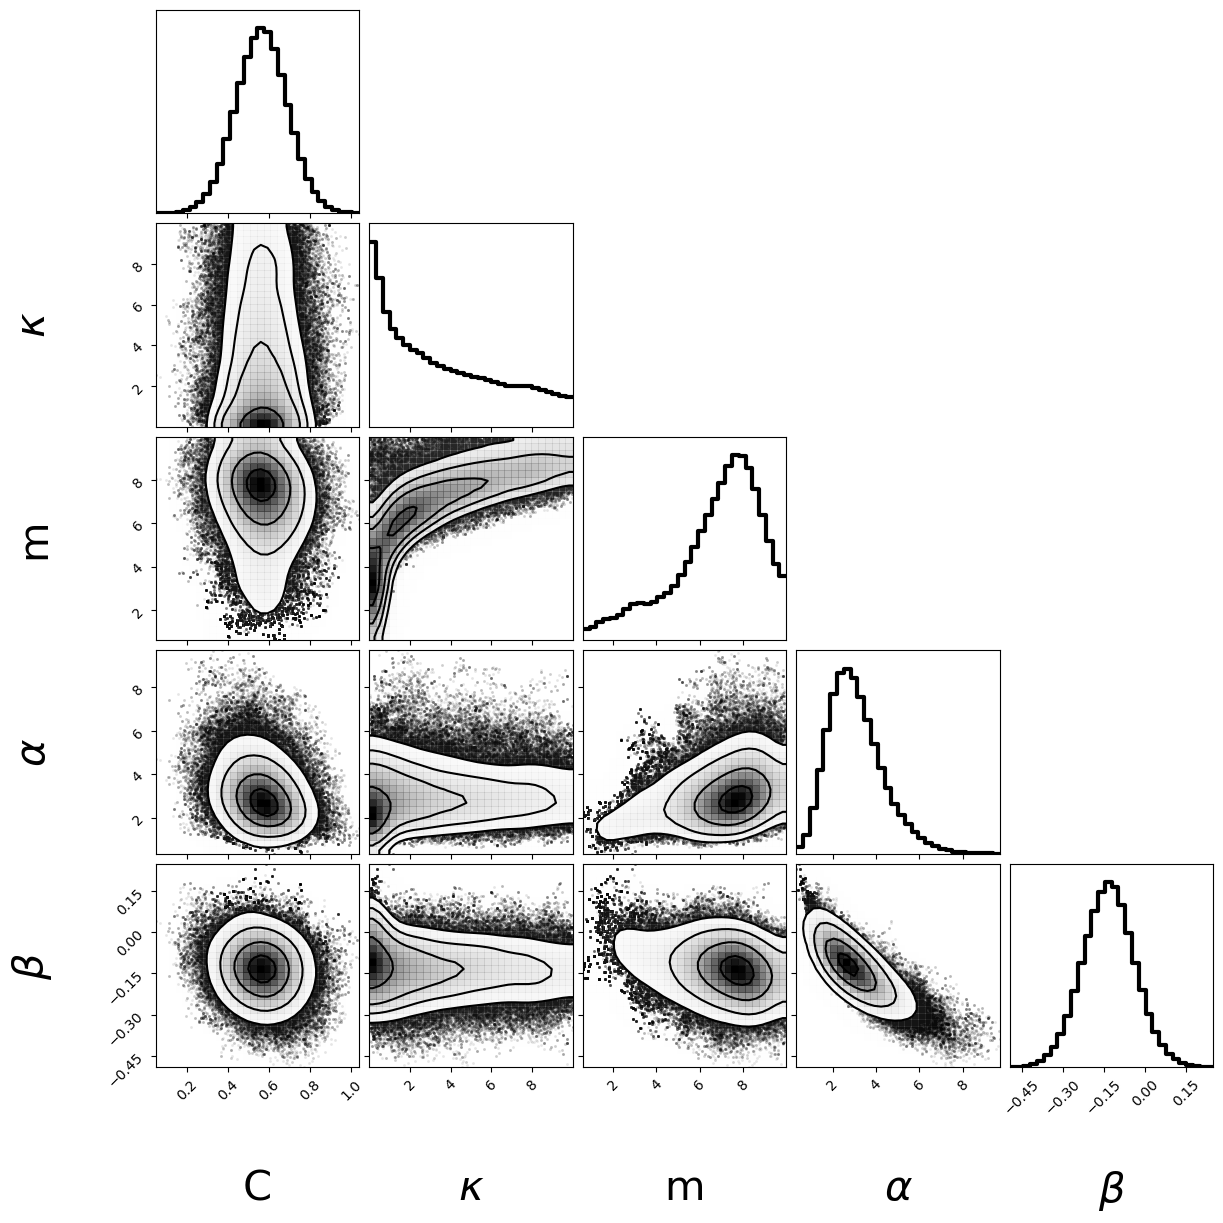

In [26]:

figure = corner.corner(all_chains_sel,
    labels=['C', r'$\kappa$', 'm', r'$\alpha$', r'$\beta$'],
    labelpad=0.2,
                       bins=30,
    label_kwargs={"fontsize":30},
                      hist_kwargs= {"linewidth":3},
    quantiles=None
#                        ,truths=[0,1], truth_color='r'
                       ,
    smooth=(1.7)
                       ,
    smooth1d=1.0,
    #truths=[ 0.56558452 , 3.32421671  ,6.93634976 , 3.05943727 ,-0.13370205],
    #truth_color='red'
                      )


width = 12
height = 12
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)

### Downsampling the parameter set

In [30]:
rng = np.random.default_rng(22)

idx = rng.choice(all_chains_sel.shape[0], size=10000, replace=False)

alpha_rand = all_chains_sel[idx]
posterior_rand = all_chains_post_sel[idx]



### Geometric median of Downsampled set

In [32]:
from scipy.spatial.distance import cdist
from scipy.optimize import minimize


def objective(p):
    return np.sum(np.linalg.norm(alpha_rand - p, axis=1))

res = minimize(objective, np.mean(alpha_rand, axis=0))
geometric_median = res.x

print(geometric_median)

[ 0.56558452  3.32421658  6.93634963  3.05943732 -0.13370202]


### Sampling to propogate slope to NLD

In [33]:
rng = np.random.default_rng(23)


idx_slopes = rng.choice(alpha_rand.shape[0], size=300, replace=False)

alpha_rand_slopes = alpha_rand[idx_slopes]

#np.savetxt('output_data/gsf_post.txt', alpha_rand_slopes, fmt='%.6f')

### Constructructing TALYS2.0 models to draw the resultant band produced by parameter sampling

In [35]:
df_base = df_construct.copy()


def func_model_gsf(params):

     # f(e1)  --- constants
    ftable=1
    C= 0
    U =  6.827386
    eta =3
    
    #f(M1)-- constants
    upbende =0
    upbendc = 10**(-6)

    final_upbend = upbende+params[2]
    
    # f(e1) construction
    e1= params[0]*ftable *  df_base['f(E1)'].values +  (C* (U-df_base['energy'].values))/(1+np.exp( df_base['energy'].values-eta))
    
    #f(m1) construction
    m1 =  df_base['f(M1)'].values +  params[1]*upbendc * np.exp(-1*(final_upbend)*df_base['energy'].values)

    gsf_t2 = m1+e1
    
    return gsf_t2

(70,)
(70,)


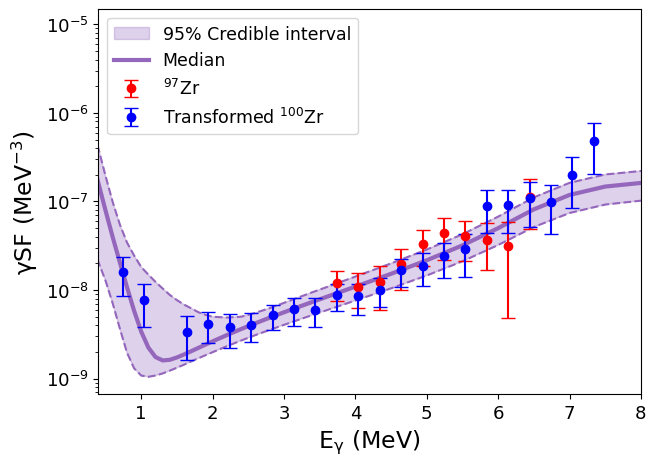

In [36]:
# draw the plot

plt.rcParams['figure.figsize']=(10.4,5.4)



np.random.seed(142857)


func_rand=[func_model_gsf(alpha) for alpha in alpha_rand]

fig, ax = plt.subplots(figsize=(7,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))
lower = (np.percentile(func_rand, 2.5, axis = 0))

prediction_color_number=4


ax.fill_between(df_base['energy'].values, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible interval')

ax.plot(df_base['energy'].values, median, color=colors[prediction_color_number],linewidth=3,label='Median')
ax.plot(df_base['energy'].values, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(df_base['energy'].values, upper, color=colors[prediction_color_number],linestyle='dashed')



# 97Zr data
ax.errorbar(energy_97, gsf_97, yerr=error_97, fmt='o',color ='red', capsize=5,label='$^{97}\mathrm{Zr}$')



# median transformed 100Zr data
ny= (1/geometric_median[3])*np.exp(-geometric_median[4]*energy_100)*gsf_100
ndy= (1/geometric_median[3])*np.exp(-geometric_median[4]*energy_100)*error_100



plt.errorbar(
        energy_100, ny, yerr=ndy,
        fmt="o",
        color= 'blue',      # marker/line color
        ecolor='blue' ,capsize=5,label ='Transformed $^{100}\mathrm{Zr}$' )  # error bar color




plt.yscale("log")



plt.xlim(0.4, 8)
#plt.ylim(3*10**(-10),10**(-6))


ax.set_xlabel(r'E$_{\mathrm{\gamma}}$ ($\mathrm{MeV}$)', fontsize=17)
ax.set_ylabel(r'$\mathrm{\gamma}$SF (MeV$^{-3}$)',fontsize=17)


plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)


plt.legend(loc ='upper left', fontsize=12.5)


#plt.savefig(r"bayesian_gsf.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

